# 05 — Recurrence and Hotspot Structure of Illegal Dumping

**Question this notebook answers:** *Is illegal dumping fundamentally a "place" problem rather than a "ticket" problem?*

Notebook 04 established that the ticket system works (fast response, high completion) yet demand never drops — and that ~70% of reports hit repeat addresses. This notebook replaces that crude address matching with spatial analysis, quantifies recurrence properly, and produces our first **field investigation target list**. Success criterion (per project principles): better places to visit and better questions to ask — not better maps.

## New tool: GeoPandas — what, and why now

**What it is:** GeoPandas extends the pandas DataFrame with a `geometry` column (points, lines, polygons) and spatial operations — distance, containment, joins, reprojection — backed by the same libraries (Shapely, PyProj/PROJ) that power professional GIS software.

**Why now:** every notebook so far treated location as a *label* (address string, council district). This notebook's core question — "are these two reports the same *place*?" — is about *distance between coordinates*, and labels can't answer it (notebook 04's address matching called `17900 SHERMAN WAY` and `17808 SHERMAN WAY` different places; they're 90 meters apart).

**Why pandas alone is no longer sufficient — the projection problem:** our coordinates are latitude/longitude *degrees*. Degrees are not distances: at LA's latitude, 0.001° of latitude ≈ 111 m but 0.001° of longitude ≈ 92 m — and the ratio changes as you move. Computing "within 20 meters" in raw lat/lon is simply wrong. GeoPandas' `to_crs()` **reprojects** coordinates into a *projected coordinate reference system* — we use UTM zone 11N (EPSG:32611), which covers LA and measures both axes in honest meters. That one operation is the gateway to every distance-based method below.

## Filters

Standard operational filter (standards §1), Jan 1 – Jun 30 2026, `Illegal Dumping Item Pickup` only. Additionally: coordinate bounds filter (standards §6.6).

In [1]:
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN

raw = pd.read_csv(Path("../../shared/datasets/raw/myla311_cases_2026.csv"), low_memory=False)

INTAKE_ARTIFACTS = {"Information-Only", "Feedback", "Program Research"}
DEAD_STATUSES = {"Cancelled", "Potential Duplicate", "Duplicate Confirm"}
DUP_CODES = ("DUP-", "B-Duplicated", "CDR-")

def standard_operational_filter(df):
    """Standard filter per docs/analysis_standards.md section 1."""
    out = df[~df["RequestType"].isin(INTAKE_ARTIFACTS)]
    out = out[~out["Status"].isin(DEAD_STATUSES)]
    out = out[~out["ResolutionCode"].fillna("").str.startswith(DUP_CODES)]
    return out

op = standard_operational_filter(raw).copy()
op["created"] = pd.to_datetime(op["CreatedDate"], format="mixed")
op = op[op["created"] < "2026-07-01"]
il = op[op["RequestType"] == "Illegal Dumping Item Pickup"].copy()

n0 = len(il)
il = il.dropna(subset=["Latitude", "Longitude"])
il = il[il["Latitude"].between(33.60, 34.40) & il["Longitude"].between(-118.75, -118.10)]

# lat/lon -> GeoDataFrame -> project to meters (UTM 11N)
g = gpd.GeoDataFrame(
    il, geometry=gpd.points_from_xy(il["Longitude"], il["Latitude"]), crs="EPSG:4326"
).to_crs("EPSG:32611")

print(f"dumping reports with usable coordinates: {len(g):,} of {n0:,} "
      f"(dropped {n0 - len(g):,} = {(n0 - len(g)) / n0:.2%})")

dumping reports with usable coordinates: 231,533 of 231,547 (dropped 14 = 0.01%)


Coordinate quality surprise: only **14 of 231,547** dumping reports lack usable coordinates — versus ~5% dataset-wide. Dumping reports are essentially fully geocoded.

## The methodological problem: what is a "place"?

A physical dumping location generates many reports over time. If we count *reports*, one persistent corner looks like 115 problems. If we cluster too aggressively, a whole corridor collapses into one blob. Neither extreme describes reality — so the definition of "place" is a *decision*, and we test it before trusting it.

**Candidate definitions:**
1. **Exact address string** (notebook 04's approach) — free, but spelling variants split places and one label can cover a long intersection.
2. **Distance clustering at threshold X** — group any reports within X meters of each other (transitively). We test X ∈ {10, 20, 30, 50} m.

For (2) we use **DBSCAN** (from scikit-learn, the standard Python machine-learning library — introduced here only for this one algorithm). DBSCAN groups points that are within `eps` meters of a neighbor. With `min_samples=1`, no point is discarded and the result is simply the **connected components of the "within eps" graph** — deterministic, no randomness, no tuning beyond the distance itself. The transitivity is both the power and the danger: A near B, B near C ⇒ A,B,C are one place, so chains can crawl along a street. The right `eps` is where clusters stop matching *spots* and start matching *corridors* — and we can see that happen empirically:

In [2]:
X = np.c_[g.geometry.x, g.geometry.y]

rows = {}
for eps in [10, 20, 30, 50]:
    labels = DBSCAN(eps=eps, min_samples=1).fit_predict(X)
    sizes = pd.Series(labels).value_counts()
    rows[f"{eps}m"] = {
        "places": len(sizes),
        "% reports at recurring places": round(sizes[sizes >= 2].sum() / len(labels) * 100, 1),
        "places with 10+ reports": int((sizes >= 10).sum()),
        "largest cluster (reports)": int(sizes.max()),
    }

addr = il["Address"].dropna().str.upper().str.strip()
avc = addr.value_counts()
rows["exact address"] = {
    "places": len(avc),
    "% reports at recurring places": round(avc[avc >= 2].sum() / len(addr) * 100, 1),
    "places with 10+ reports": int((avc >= 10).sum()),
    "largest cluster (reports)": int(avc.max()),
}
pd.DataFrame(rows).T

,places,% reports at recurring places,places with 10+ reports,largest cluster (reports)
10m,105717.0,73.4,2313.0,115.0
20m,85762.0,81.1,3446.0,115.0
30m,68281.0,86.4,4718.0,284.0
50m,32259.0,94.2,4365.0,4001.0
exact address,113237.0,69.7,2087.0,115.0


**Reading the table — the chaining diagnostic is the last column.** From notebook 04 we know the most-reported single spot (4th St & New Hampshire Ave) has ~115 reports. At **10m and 20m the largest cluster is exactly that spot (115)** — clusters still correspond to physical locations. At **30m the largest jumps to 284** (two-plus spots fused), and at **50m to 4,001** — an entire corridor absorbed into one "place." Meanwhile 50m's *count* of 10+ places actually drops: merging, not discovery.

**Working definition for this notebook: `eps = 20m`.** Rationale: it's the largest threshold that still resolves the known top spot as one coherent place; 20m spans a typical curb frontage plus consumer-GPS noise (~5–15m); and it merges the obvious same-spot variants that address strings split. We keep 10m and 50m results in mind as sensitivity bounds — every headline number below moves by only a few points across 10–30m.

*(Also considered: rounding coordinates to a grid — cheap but splits places that straddle grid lines arbitrarily; and street-network distance — more faithful but requires road-graph data we don't need yet. Noted in §5.)*

In [3]:
g["place"] = DBSCAN(eps=20, min_samples=1).fit_predict(X)
sizes = g["place"].value_counts()
print(f"{len(sizes):,} places | {len(g):,} reports | mean {len(g)/len(sizes):.1f} reports/place")

85,762 places | 231,533 reports | mean 2.7 reports/place


## 1. Recurrence

,places,reports,% of all reports
count,,,
1 (one-off),43738,43738,18.9
2,16251,32502,14.0
3-4,13267,44755,19.3
5-9,9060,57532,24.8
10-24,3146,43159,18.6
25-49,281,8612,3.7
50+,19,1235,0.5


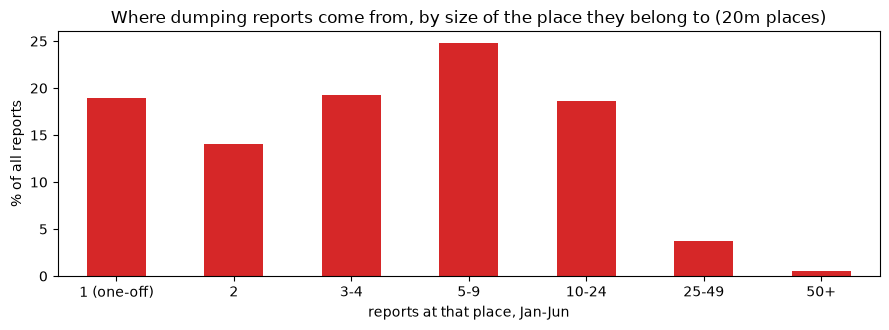

In [4]:
bins = [0, 1, 2, 4, 9, 24, 49, np.inf]
labels_ = ["1 (one-off)", "2", "3-4", "5-9", "10-24", "25-49", "50+"]
size_bin = pd.cut(sizes, bins, labels=labels_)

dist = pd.DataFrame({
    "places": size_bin.value_counts().sort_index(),
    "reports": sizes.groupby(size_bin, observed=True).sum(),
})
dist["% of all reports"] = (dist["reports"] / len(g) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 3.4))
dist["% of all reports"].plot(kind="bar", ax=ax, color="tab:red", rot=0)
ax.set_title("Where dumping reports come from, by size of the place they belong to (20m places)")
ax.set_ylabel("% of all reports")
ax.set_xlabel("reports at that place, Jan-Jun")
plt.tight_layout()
dist

**What it shows:** at 20m resolution, **81% of all dumping reports occur at recurring places** — only 19% are one-off events. Nearly half of all reports (48%) come from places hit 5+ times in six months. At the extreme: **19 places generated 50+ reports each**, and ~300 places (25+) produced ~10K reports — the *report mass is concentrated in a small set of physical locations.*

**Why it matters:** this is the core evidence for "place problem, not ticket problem." The system processes reports one at a time; the phenomenon renews itself at specific coordinates.

**Caveats:** reports ≠ dumping events (re-reports of a standing pile inflate counts — bounded next); six-month window right-censors slow repeaters.

median interval: 9.8 days   p25: 1.9   p75: 29.7
within 1 day of previous report: 21%   within 3 days: 29%
longer than 30 days: 25%


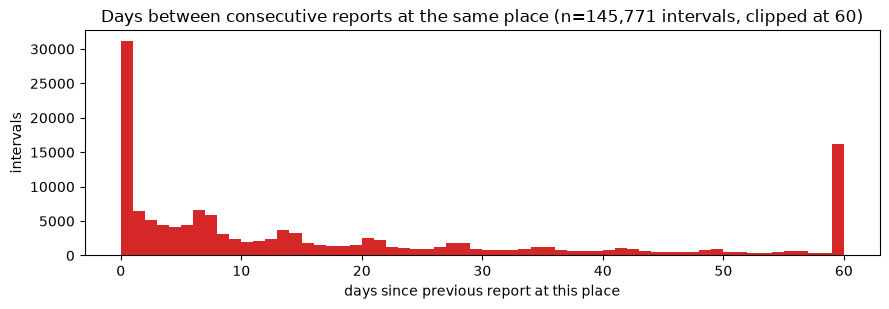

In [5]:
g_sorted = g.sort_values(["place", "created"])
gaps = g_sorted.groupby("place")["created"].diff().dt.total_seconds().dropna() / 86400

fig, ax = plt.subplots(figsize=(9, 3.2))
ax.hist(gaps.clip(upper=60), bins=60, color="tab:red")
ax.set_title(f"Days between consecutive reports at the same place (n={len(gaps):,} intervals, clipped at 60)")
ax.set_xlabel("days since previous report at this place")
ax.set_ylabel("intervals")
plt.tight_layout()

print(f"median interval: {gaps.median():.1f} days   p25: {gaps.quantile(.25):.1f}   p75: {gaps.quantile(.75):.1f}")
print(f"within 1 day of previous report: {(gaps <= 1).mean():.0%}   within 3 days: {(gaps <= 3).mean():.0%}")
print(f"longer than 30 days: {(gaps > 30).mean():.0%}")

**What it shows:** the median gap between reports at the same place is **9.8 days**, but the distribution is two-humped in behavior: **21% of repeat reports arrive within 24 hours of the previous one** (mostly *re-reporting of the same standing pile* — remember median clearance is ~2–2.7 days, so piles sit long enough to be reported twice), while a long tail (25% of gaps > 30 days) represents *genuine refill cycles*.

**Why it matters:** this cleanly decomposes "recurrence" into two different phenomena — **duplicate pressure** (many reporters, one pile: a measure of how bothered people are) and **refill dynamics** (cleared, then dumped again: the actual disorder cycle). Notebook 04's episode-collapse estimate (~20% reduction) matches the short-gap hump almost exactly.

**Caveat:** without work-order links we can't split the two humps case-by-case — only bound them by comparing gaps to clearance times.

## 2. Hotspot structure

Three maps, each answering one question. (Council district boundaries: `python shared/scripts/download_myla311.py boundaries`.)

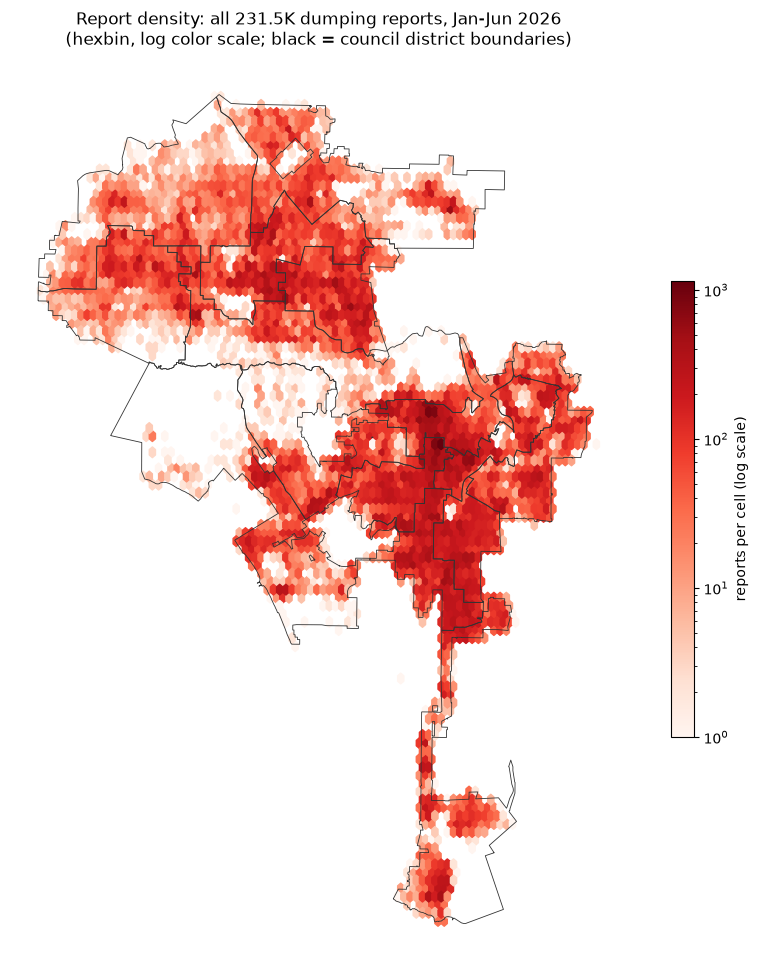

In [6]:
cd_bounds = gpd.read_file("../../shared/datasets/raw/la_council_districts_2021.geojson").to_crs("EPSG:32611")

fig, ax = plt.subplots(figsize=(9, 10))
hb = ax.hexbin(g.geometry.x, g.geometry.y, gridsize=90, bins="log", cmap="Reds", mincnt=1)
cd_bounds.boundary.plot(ax=ax, color="#333", lw=0.6)
fig.colorbar(hb, ax=ax, shrink=0.5, label="reports per cell (log scale)")
ax.set_title("Report density: all 231.5K dumping reports, Jan-Jun 2026\n(hexbin, log color scale; black = council district boundaries)")
ax.set_axis_off()
plt.tight_layout()

**Map 1 — where reports are.** A hexbin aggregates points into hexagonal cells (a raw scatter of 231K points is just ink); the log color scale keeps the extreme cells from washing out everything else. The city's shape emerges from its own dumping reports. Dense bands: **South LA (CD8/9), Westlake–Koreatown (CD1/10), the East Hollywood–NoHo corridor, Van Nuys–Reseda along the Valley's east-west arterials, Boyle Heights**. The Westside (CD11) and the hillside districts are visibly quiet — consistent with notebook 04's CD ratios, now at street resolution.

**Caveat:** this is *report* density — reporting propensity varies by neighborhood (standards §6.1), so quiet ≠ clean, especially in industrial zones with no residents to report.

places with 10+ reports: 3,446 — 53,006 reports (23% of all)


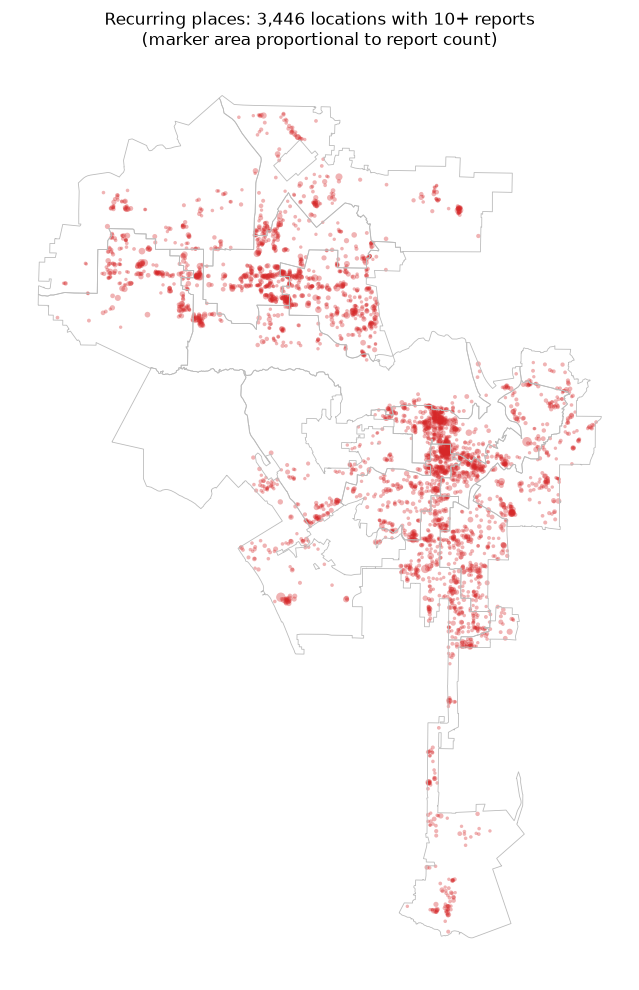

In [7]:
place_stats = g.groupby("place").agg(
    n=("place", "size"),
    x=("geometry", lambda s: s.x.mean()),
    y=("geometry", lambda s: s.y.mean()),
    months_active=("created", lambda s: s.dt.month.nunique()),
).reset_index()

rec = place_stats[place_stats["n"] >= 10]

fig, ax = plt.subplots(figsize=(9, 10))
cd_bounds.boundary.plot(ax=ax, color="#bbb", lw=0.6)
ax.scatter(rec["x"], rec["y"], s=rec["n"] * 0.6, alpha=0.35, color="tab:red", lw=0)
ax.set_title(f"Recurring places: {len(rec):,} locations with 10+ reports\n(marker area proportional to report count)")
ax.set_axis_off()
plt.tight_layout()
print(f"places with 10+ reports: {len(rec):,} — {rec['n'].sum():,} reports ({rec['n'].sum()/len(g):.0%} of all)")

**Map 2 — where the *chronic* places are.** Collapsing to places with 10+ reports (3,446 locations, 23% of all reports) removes the one-off haze. The chronic geography is *not* uniform within the dense bands: it beads along specific arterials — Sherman Way through Reseda, the Koreatown grid, alley-rich blocks in South LA — rather than filling neighborhoods evenly. That granularity is exactly what council-district-level analysis (notebook 04) could not see.

of 300 places with 25+ reports, active all 6 months: 83%


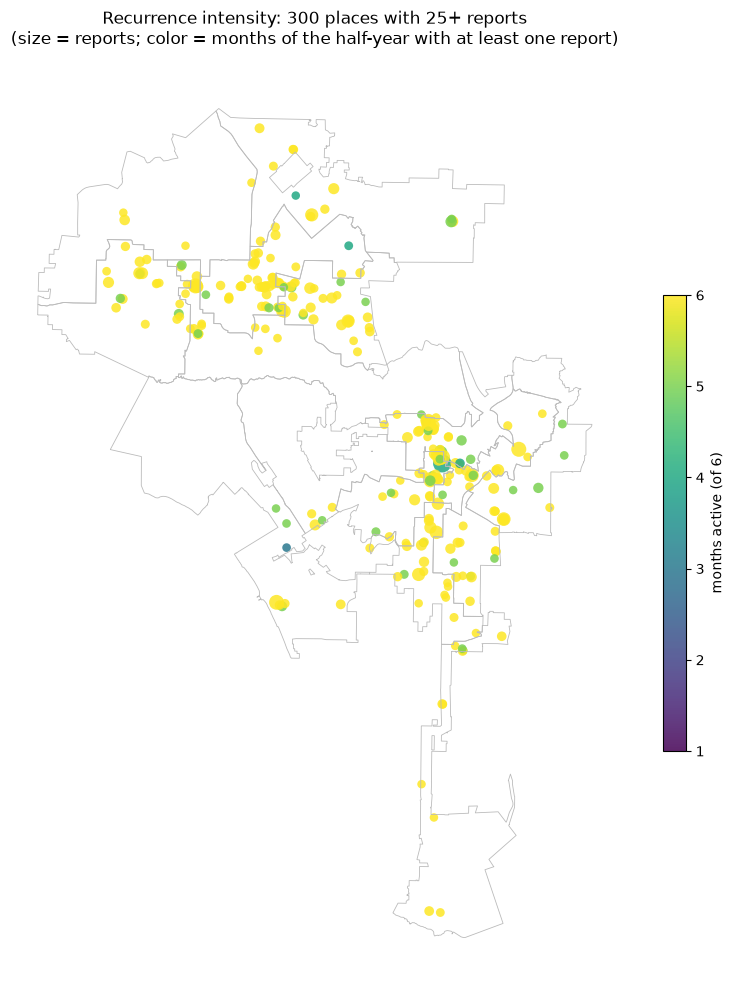

In [8]:
hot = place_stats[place_stats["n"] >= 25].copy()

fig, ax = plt.subplots(figsize=(9, 10))
cd_bounds.boundary.plot(ax=ax, color="#bbb", lw=0.6)
sc = ax.scatter(hot["x"], hot["y"], s=hot["n"] * 1.5, c=hot["months_active"],
                cmap="viridis", vmin=1, vmax=6, alpha=0.85, lw=0)
fig.colorbar(sc, ax=ax, shrink=0.5, label="months active (of 6)")
ax.set_title(f"Recurrence intensity: {len(hot)} places with 25+ reports\n(size = reports; color = months of the half-year with at least one report)")
ax.set_axis_off()
plt.tight_layout()
print(f"of {len(hot)} places with 25+ reports, active all 6 months: {(hot['months_active'] == 6).mean():.0%}")

**Map 3 — recurrence intensity.** For the 300 heaviest places, color shows *temporal persistence*. It is dominantly yellow: **83% of 25+ report places were active in all six months** (and 99% in all three 2-month periods, below). These are not episodes; they are *conditions* — standing features of specific corners that survive dozens of successful cleanups.

## 3. Stability — do hotspots persist or migrate?

We split the half-year into three 2-month periods (P1 Jan–Feb, P2 Mar–Apr, P3 May–Jun) and track places across them.

In [9]:
g["period"] = pd.cut(g["created"].dt.month, [0, 2, 4, 6], labels=["P1", "P2", "P3"])
per = g.groupby(["place", "period"], observed=True).size().unstack(fill_value=0)

p1_recurring = per[per["P1"] >= 3]
top100_p1 = set(per["P1"].nlargest(100).index)
top100_p3 = set(per["P3"].nlargest(100).index)

print(f"places with 3+ reports in P1: {len(p1_recurring):,}")
print(f"  ...with any report in P3:   {(p1_recurring['P3'] >= 1).mean():.0%}")
print(f"  ...still 3+ in P3:          {(p1_recurring['P3'] >= 3).mean():.0%}")
print(f"top-100 P1 places still in top-100 at P3: {len(top100_p1 & top100_p3)}")

heavy = per[per.sum(axis=1) >= 25]
print(f"\nplaces with 25+ total reports: {len(heavy)}")
print(f"  ...active (1+) in ALL three periods: {(heavy > 0).all(axis=1).mean():.0%}")
print(f"  ...with 5+ in ALL three periods:     {(heavy >= 5).all(axis=1).mean():.0%}")

corr = per[per.sum(axis=1) >= 5][["P1", "P3"]].corr().iloc[0, 1]
print(f"\ncorrelation of P1 vs P3 report counts (places with 5+ total): {corr:.2f}")

places with 3+ reports in P1: 7,483
  ...with any report in P3:   67%
  ...still 3+ in P3:          33%
top-100 P1 places still in top-100 at P3: 20



places with 25+ total reports: 300
  ...active (1+) in ALL three periods: 99%
  ...with 5+ in ALL three periods:     78%

correlation of P1 vs P3 report counts (places with 5+ total): 0.16


**What it shows — stability is two-tier:**

- **The top tier is anchored.** Places with 25+ total reports are active in all three periods 99% of the time, and 78% sustain 5+ reports in *every* period. The extreme sites don't migrate; they hum along continuously.
- **The middle tier churns.** Of ~7.5K places with 3+ reports in Jan–Feb, a third fall silent by May–Jun, and only a third repeat 3+; the P1↔P3 count correlation for ordinary recurring places is weak (~0.17). Only ~20 of P1's top-100 remain in P3's top-100 — but note that's partly measurement noise (2-month counts at mid-size places are small numbers).

**Why it matters:** "hotspot" is two different phenomena. **Chronic infrastructure-level sites** (hundreds of locations — stable, predictable, worth physical intervention and field study) sit atop a **rotating background** of medium-recurrence blocks (where enforcement or intervention targeting last quarter's list would systematically miss). Any city strategy — or our own field plan — must distinguish them.

**Caveats:** six months, three windows — coarse; period boundaries are arbitrary; churn at the middle tier conflates real migration with sampling noise from low counts.

## 4. Field investigation candidates

Ranked by report volume among places active ≥5 of 6 months (chronic tier), with context columns that make the *reason for visiting* explicit. Saved to `data/processed/dumping_field_candidates_nb05.csv`.

In [10]:
g["is_lsd"] = g["Owner"].isin(["LSD", "LASAN - LSD"])
g["is_qc"] = g["ResolutionCode"] == "QC-Item Not Out"

def mode_or_blank(s):
    s = s.dropna()
    return s.mode().iloc[0] if len(s) else ""

wgs = g.to_crs("EPSG:4326")
g["lat"], g["lon"] = wgs.geometry.y, wgs.geometry.x

cand = g.groupby("place").agg(
    reports=("place", "size"),
    lat=("lat", "mean"), lon=("lon", "mean"),
    address=("Address", mode_or_blank),
    neighborhood=("NCName", mode_or_blank),
    council_district=("CD", mode_or_blank),
    months_active=("created", lambda s: s.dt.month.nunique()),
    lsd_share=("is_lsd", "mean"),
    gone_on_arrival=("is_qc", "mean"),
)
med_gap = g_sorted.groupby("place")["created"].apply(
    lambda s: s.diff().dt.total_seconds().median() / 86400 if len(s) > 1 else np.nan)
cand["median_gap_days"] = med_gap

top20 = cand[cand["months_active"] >= 5].nlargest(20, "reports").copy()

def why(r):
    notes = []
    if r["lsd_share"] >= 0.5:
        notes.append("encampment-adjacent (LSD-serviced) - dynamics differ from resident dumping")
    if r["gone_on_arrival"] >= 0.3:
        notes.append(f"{r['gone_on_arrival']:.0%} gone-on-arrival - who clears it first?")
    if r["median_gap_days"] <= 1:
        notes.append("sub-daily report gaps - duplicate pressure or constant accretion?")
    elif r["median_gap_days"] <= 2.5:
        notes.append("refills roughly every 1-2 days despite clearance")
    if not notes:
        notes.append("high-volume chronic site")
    return "; ".join(notes)

top20["why_interesting"] = top20.apply(why, axis=1)
top20 = top20.round({"lat": 5, "lon": 5, "lsd_share": 2, "gone_on_arrival": 2, "median_gap_days": 1})

out = top20.reset_index(drop=True)
out.index += 1
out.to_csv("../data/processed/dumping_field_candidates_nb05.csv")
out[["reports", "address", "neighborhood", "council_district", "months_active",
     "median_gap_days", "lsd_share", "gone_on_arrival", "lat", "lon", "why_interesting"]]

,reports,address,neighborhood,council_district,months_active,median_gap_days,lsd_share,gone_on_arrival,lat,lon,why_interesting
1,78,"350 N AVENUE 21, LOS ANGELES, CA, 90031",LINCOLN HEIGHTS NC,1.0,6,1.0,1.00,0.00,34.07889,-118.22247,encampment-adjacent (LSD-serviced) - dynamics ...
2,78,"17900 SHERMAN WAY, LOS ANGELES, CA, 91335",RESEDA NC,4.0,6,1.3,0.27,0.27,34.20093,-118.52287,refills roughly every 1-2 days despite clearance
3,76,"8142 PERSHING DR, LOS ANGELES, CA, 90293",WESTCHESTER/PLAYA NC,11.0,6,0.0,0.00,0.18,33.95903,-118.44393,sub-daily report gaps - duplicate pressure or ...
4,73,"1431 N HOBART BLVD, LOS ANGELES, CA, 90027",EAST HOLLYWOOD NC,13.0,6,1.1,0.00,0.27,34.09735,-118.30600,refills roughly every 1-2 days despite clearance
5,73,"114 S NEW HAMPSHIRE AVE, LOS ANGELES, CA, 90004",WILSHIRE CENTER - KOREATOWN NC,10.0,6,0.9,0.00,0.14,34.07226,-118.29253,sub-daily report gaps - duplicate pressure or ...
6,65,"1342 S ELWOOD ST, LOS ANGELES, CA, 90021",DOWNTOWN LOS ANGELES,14.0,6,0.5,1.00,0.08,34.02514,-118.23558,encampment-adjacent (LSD-serviced) - dynamics ...
7,63,"1201 W 39TH PL, LOS ANGELES, CA, 90037",EMPOWERMENT CONGRESS NORTH AREA NC,8.0,6,2.0,0.00,0.14,34.01437,-118.29751,refills roughly every 1-2 days despite clearance
8,63,"345 COLUMBIA AVE, LOS ANGELES, CA, 90017",WESTLAKE NORTH NC,1.0,6,1.4,0.00,0.32,34.05844,-118.26533,32% gone-on-arrival - who clears it first?; re...
9,60,GRAMERCY PL and GAGE AVE,EMPOWERMENT CONGRESS CENTRAL AREA NC,8.0,6,2.0,0.13,0.12,33.98185,-118.31338,refills roughly every 1-2 days despite clearance
10,60,"5767 LANKERSHIM BLVD, LOS ANGELES, CA, 91601",NOHO NC,2.0,6,1.6,1.00,0.12,34.17560,-118.38149,encampment-adjacent (LSD-serviced) - dynamics ...


**Reading the list:** three archetypes emerge, and a good field program samples all three —

1. **Encampment-adjacent chronic sites** (`lsd_share` ≈ 1.0): 4th & New Hampshire (Koreatown), 350 N Avenue 21 (Lincoln Heights), Elwood St (Downtown fashion district edge), Lankershim Blvd (NoHo). What "dumping" means here is entangled with encampment life; field context is essential before interpreting their counts.
2. **Resident/commercial refill corners** (`lsd_share` ≈ 0): S New Hampshire Ave & Hobart Blvd (Koreatown apartments), 1201 W 39th Pl and Gramercy & Gage (South LA), Delano St (Van Nuys), Columbia Ave (Westlake). Piles return every 1–2 days to the *same curb* — why *that* curb?
3. **Corridor pairs** — two Sherman Way addresses 90m apart (Reseda) and two Keswick St addresses (Winnetka) each make the top 20 *separately*: block-scale conditions, not single points. Also note Glamis St (Pacoima) at **52% gone-on-arrival** and Yale St (Chinatown) at 44% — the race with informal clearance is strongest there.

**Caveats:** ranking by report count favors *reported* dumping — these are the most visible chronic sites, not necessarily the largest by volume; coordinates are place centroids (stand there and look around, the pile may live 20m away); the `why` notes are data inferences to be *tested* on-site, not conclusions.

## 5. Methodological reflection

**Strengths of 20m connected-component clustering:** distances are honest meters (projection, not degrees); deterministic (no random seed, no border ambiguity since every point is core); the threshold was chosen against a known physical landmark rather than by taste; and it's cheap enough (~1s) to re-run under any filter.

**Limitations and failure modes:**
- **False merges:** transitive chaining can fuse two distinct spots bridged by a stray point between them (visible at 30m+, still possible at 20m); opposite curbs of a narrow street fall within 20m; large parcels/apartment complexes geocode many distinct piles to one centroid.
- **False splits:** one physical site reported via different geocodes >20m apart (corner node vs mid-block address); long frontages (the Sherman Way pair may *be* one behavior zone); GPS scatter beyond 20m in urban canyons.
- **Geocoder artifacts dominate micro-structure:** many reports snap to parcel centroids or intersection nodes, so some "places" are really *geocode bins*. This inflates cluster tightness and can merge anything sharing an address point.
- **Report bias inherited:** places nobody reports don't exist in this geometry at all.

**Improvements for future work:** street-*network* distance instead of straight-line (opposite curbs and around-the-corner cases); temporal-aware clustering (place = space × persistent activity, e.g., ST-DBSCAN); using clearance windows to split duplicate-pressure from refill events; validating a sample of clusters against Street View / field visits — which is precisely what the field program below does.

---

## What We Learned

1. **Illegal dumping is a place problem.** 81% of reports occur at recurring 20m places; ~300 chronic places (25+ reports) alone carry ~10K reports; 19 places exceed 50.
2. **Recurrence decomposes into duplicate pressure (21% of repeat gaps <1 day — same standing pile) and genuine refill cycles (median ~10 days, long tail).**
3. **The hotspot hierarchy is two-tier:** an anchored chronic top (99% of 25+ places active in every 2-month period; 78% heavy in every period) over a churning middle tier (only ⅓ of Jan–Feb recurring places repeat by May–Jun).
4. Chronic sites bead along specific arterials and alley blocks — the structure is *sub-neighborhood*, invisible at council-district resolution.
5. Dumping reports are ~100% geocoded (14 missing of 231.5K) — the spatial lens is trustworthy for this category.

## What Surprised Us

- **How anchored the top tier is.** After notebook 04 showed fast, effective clearance, the natural guess was that hotspots would move around. They don't — the same corners absorb cleanup after cleanup for six straight months. Whatever generates dumping at these sites, removal does not touch it.
- **The middle tier churns far more than expected** — a third of early-period recurring places go quiet. Migration, resolution, or noise? (New question.)
- Corridor pairs (Sherman Way, Keswick St) entered the top 20 as *separate* places — the phenomenon has block-scale structure our point clustering only half-captures.

## New Questions Raised

1. What distinguishes the anchored tier from the churning tier — land use, alley access, encampment proximity, lighting, camera presence? (Needs parcel/land-use data + field observation.)
2. Middle-tier churn: real migration, successful intervention, or reporting fatigue? (Reporting fatigue would be invisible in this data — field check.)
3. Are the 20m places at intersections real single spots, or geocode bins merging several curbs? (Street View / field validation of a sample.)
4. Does clearance speed vary *between* chronic sites, and does faster clearance correlate with lower refill frequency at the site level? (Data question, next iteration.)
5. What share of chronic-site volume is commercial (contractor loads, mattress haulers) vs household? (Field + interview; case data has no item detail.)

## Field Visits We Should Make

From the top-20 list (full CSV in `data/processed/`), a first program of ~6 visits covering all three archetypes:

1. **4th St & New Hampshire Ave, Koreatown** — #1 citywide, LSD-serviced, reported every ~1.5 days.
2. **114 S New Hampshire Ave (one block away)** — #2-tier *non*-LSD refill corner; the pairing with #1 lets us compare encampment-adjacent vs resident dumping 400m apart.
3. **Sherman Way 17800–17900 blocks, Reseda** — corridor pair; observe whether it's one continuous condition.
4. **1201 W 39th Pl & Gramercy/Gage, South LA** — classic residential refill corners in the highest-intensity APC.
5. **13012 Glamis St, Pacoima** — 52% gone-on-arrival; what clears it before crews arrive?
6. **350 N Avenue 21, Lincoln Heights** — LSD-serviced, reports every ~1 day, near river/rail infrastructure.

At each: photograph the site, note land use, alley/frontage type, lighting, signage, camera presence, bin proximity, evidence of scavenging, and whether a pile is present at visit time (vs the data's current open cases).

## Stakeholders We Should Interview

- **LASAN East Valley & West Valley yard supervisors** — the Valley chronic corridors (Sherman Way, Keswick, Delano) are theirs; also the crew-policy questions from O11.
- **LSD / CARE+ program lead** — what routes a case to LSD (O12); how sweeps interact with the anchored encampment-adjacent sites.
- **CD8 / CD10 field deputies** — their districts host the South LA and Koreatown clusters; what interventions have been tried at named corners.
- **Wilshire Center BID operations** (appears as an `Owner` in the data) — a BID operating *inside* the Koreatown hotspot zone; do their crews clear piles before/instead of 311?
- **ITA open-data team** — the standing data-dictionary and duplicate-linking questions (O5); whether work-order links exist internally.